# 01 — Business EDA & CFO-grade KPIs

**Goal**: Translate raw financial data into clear, benchmarkable business metrics and strategic priorities aligned with finance and executive audiences.

### What this notebook does
- Loads the SaaS financial snapshot (from Notebook 00)
- Computes **CFO-grade retention metrics**:
  - **GRR** (Gross Revenue Retention) and **NRR** (Net Revenue Retention)
  - **Churn rates** (revenue % and logo %)
  - **Reactivated ARR** as a first-class operational metric
- Builds **executive dashboards**:
  - Waterfall views (Opening>Churn>Reactivation>New>Closing) by segment
  - **Region × Segment prioritization matrix** (net contribution %)
  - Trend lines and benchmark context
- Standardizes visual grammar and terminology for cross-functional alignment

### How to Use
**Prerequisites**
```
ai-decision-intelligence-main/
├── data/processed/saas_financial_snapshot.csv         (from Notebook 00)
├── src/decision_engine/
│   ├── kpis.py                                        (KPI computation)
│   └── heatmap_region_segment.py                      (segment heatmap)
└── notebooks/01_business_eda_enhanced.ipynb           (this file)
```

**Execution**
1. Run cells in order
2. Inspect KPI tables for reasonableness (GRR, NRR, churn %)
3. Review visuals and check alignment with company benchmarks
4. Note high-priority Region × Segment combinations for strategy work

**Deliverables**
- CFO-aligned KPI summaries (GRR, NRR, churn, reactivation)
- Multi-dimensional visualizations (waterfalls, prioritization matrix, trends)
- Executive-ready narrative for board/investor presentations


## 01 — Setup & data load
Import libraries, set visual style, and load SaaS financial snapshot.

In [61]:
import sys
import importlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Add src/functions to path for shared KPI function
project_root = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
src_path = project_root / 'src' / 'functions'
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

try:
    from kpis import compute_cfo_kpis, compute_retention_metrics
    from heatmap_region_segment import plot_region_segment_heatmap
except ImportError as e:
    raise ImportError(
        f"Failed to import functions: {e}. "
        "Check src/functions/kpis.py and heatmap_region_segment.py."
    )

# Harmonized visual style
sns.set_theme(style="white")
plt.rcParams.update({
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "legend.fontsize": 9,
    "figure.figsize": (10, 5),
})
plt.rcParams['axes.grid'] = False  # remove background gridlines globally
plt.rcParams['axes.unicode_minus'] = False  # ensure minus signs render as hyphen-minus even with fonts


In [62]:
path = Path(r"C:\ai-decision-intelligence-main\data\processed\saas_financial_snapshot.csv")
data_processed = pd.read_csv(path)

# Verify schema
expected_cols = {
    'account_id','industry','country','plan_tier','region','segment',
    'gross_margin_estimated','annual_contract_value','opening_arr',
    'new_arr','churned_arr','reactivated_arr','expansion_arr','contraction_arr',
    'net_arr_change','analysis_window_start','analysis_window_end'
}
missing = expected_cols.difference(data_processed.columns)
if missing:
    raise ValueError(f"Missing columns: {missing}")

# Check for missing values before numeric normalization
numeric_cols = ['annual_contract_value','opening_arr','new_arr','churned_arr','reactivated_arr','expansion_arr','contraction_arr','net_arr_change']
missing_before = data_processed[numeric_cols].isnull().sum()
if missing_before.sum() > 0:
    raise ValueError(f"Missing values found (will NOT be replaced by 0): {missing_before[missing_before > 0].to_dict()}")

# Numeric normalization: convert to numbers
for col in numeric_cols:
    data_processed[col] = pd.to_numeric(data_processed[col], errors='coerce')

print(f"Data Loaded: {len(data_processed):,} rows × {len(data_processed.columns)} columns")

Data Loaded: 500 rows × 17 columns


In [63]:
# Define segment order (Enterprise → Corporate → SMB)
SEGMENT_ORDER = ['Enterprise','Corporate','SMB']
data_processed['segment'] = pd.Categorical(data_processed['segment'], categories=SEGMENT_ORDER, ordered=True)

print(f"Data prepared — ready for analysis")

Data prepared — ready for analysis


## 02 — Global KPIs (GRR, NRR, churn)

**Key Metrics** (opening-based, full dataset):
- **GRR** (Gross Retention Rate): 1 − (Churned / Opening ARR)
- **NRR** (Net Retention Rate): (Opening − Churned + Expansion − Contraction) / Opening ARR
- **Net Growth %**: (Net ARR) / Opening ARR
- **Reactivated ARR**: Absolute value recovered from churned accounts

Baseline KPIs establish the starting point for all downstream analysis (segment, region, scenarios).

In [64]:
kpi_input = data_processed.rename(columns={
    'opening_arr': 'opening',
    'churned_arr': 'churned',
    'new_arr': 'new',
    'reactivated_arr': 'reactivated',
    'expansion_arr': 'expansion',
    'contraction_arr': 'contraction',
})

cfo_display = compute_cfo_kpis(
    kpi_input[['opening','churned','new','reactivated','expansion','contraction']].sum().to_frame().T,
    format_output=True
)

display(cfo_display.style.set_table_styles([
    {"selector": "th, td", "props": [("white-space", "nowrap")]}
]))

,opening,churned,new,reactivated,expansion,contraction,net,gross_churn,GRR,NRR,net_growth_pct
0,4 892 k$,1 440 k$,9 281 k$,3 777 k$,228 k$,97 k$,11 749 k$,29.4%,70.6%,73.2%,240.2%


## 03 — Segment deep dive (smb, corporate, enterprise)

Understand segment-level retention health and growth dynamics. Which segments are growing, stable, or declining? Which are expansion-led vs. churn-challenged?

**What to look for:** Segment churn rates, reactivation %, and whether NRR > 100% indicates net expansion within segment. Compare Enterprise resilience vs. SMB volatility.

In [65]:
grouped_by_segment = compute_retention_metrics(
    data_processed, selected_group='segment', 
    segment_order=SEGMENT_ORDER, 
    format_output=True
    )

display(grouped_by_segment.style.set_table_styles([
    {"selector": "th, td", "props": [("white-space", "nowrap")]}
]))

,segment,opening_arr,annual_contract_value,churned_arr,new_arr,reactivated_arr,expansion_arr,contraction_arr,accounts,logos_churn,rev_churn_ratio_on_stock,gross_churn_on_opening,GRR,NRR
0,Enterprise,1 392 k$,5 047 k$,372 k$,2 406 k$,1 071 k$,124 k$,3 k$,154,13.0%,7.4%,26.7%,73.3%,82.0%
1,Corporate,2 107 k$,4 873 k$,738 k$,3 732 k$,1 646 k$,80 k$,42 k$,178,10.7%,15.1%,35.0%,65.0%,66.8%
2,SMB,1 392 k$,4 914 k$,330 k$,3 144 k$,1 060 k$,24 k$,53 k$,168,8.9%,6.7%,23.7%,76.3%,74.3%


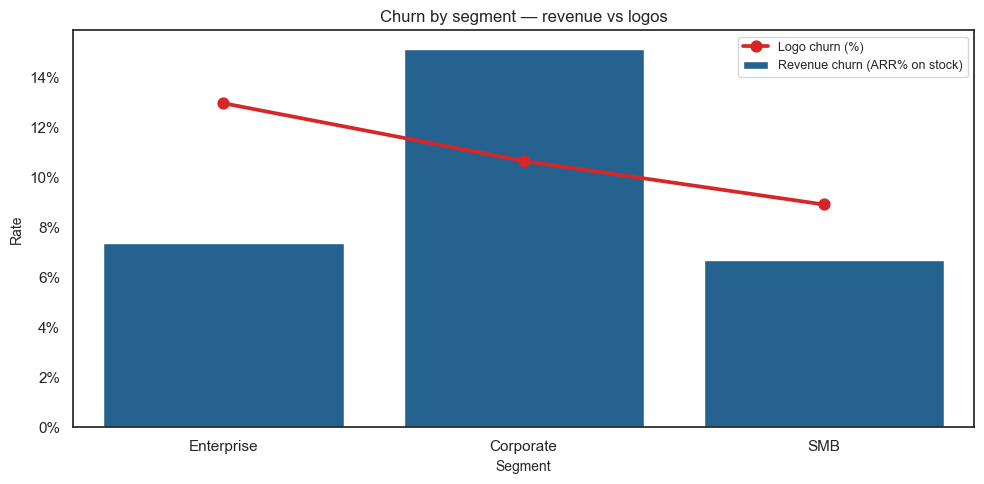

In [66]:
grouped_by_segment_forviz = compute_retention_metrics(
    data_processed, selected_group='segment', 
    segment_order=SEGMENT_ORDER, 
    format_output=False
    )

fig, ax = plt.subplots(figsize=(10,5))

sns.barplot(
    data=grouped_by_segment_forviz, x='segment', y='rev_churn_ratio_on_stock', order=SEGMENT_ORDER,
    color='#1565a0', label='Revenue churn (ARR% on stock)')

sns.pointplot(
    data=grouped_by_segment_forviz, x='segment', y='logos_churn', order=SEGMENT_ORDER, color='#d62728', label='Logo churn (%)')

ax.set_title('Churn by segment — revenue vs logos')
ax.set_xlabel('Segment')
ax.set_ylabel('Rate')
ax.yaxis.set_major_formatter(lambda x,pos: f"{x*100:.0f}%")
ax.legend()
ax.grid(False)

plt.tight_layout()
plt.show()

## 04 — Region deep dive (nam, emea, apac)

Assess geographic performance and maturity. Which regions show healthy retention (GRR > 90%) and net expansion (NRR > 100%)? Where are reactivation and new logo opportunities concentrated?

**What to look for:** Regional churn divergence, growth or decline in Net ARR, and whether regions are in stable harvest vs. growth phase.

In [67]:
grouped_by_region = compute_retention_metrics(
    data_processed, 
    selected_group='region', 
    format_output=True)

display(grouped_by_region.style.set_table_styles([
    {"selector": "th, td", "props": [("white-space", "nowrap")]}
]))

,region,opening_arr,annual_contract_value,churned_arr,new_arr,reactivated_arr,expansion_arr,contraction_arr,accounts,logos_churn,rev_churn_ratio_on_stock,gross_churn_on_opening,GRR,NRR
0,APAC,906 k$,2 810 k$,159 k$,1 578 k$,506 k$,28 k$,7 k$,81,8.6%,5.7%,17.6%,82.4%,84.7%
1,EMEA,820 k$,3 905 k$,311 k$,1 863 k$,904 k$,55 k$,37 k$,105,13.3%,8.0%,37.9%,62.1%,64.3%
2,NAM,3 166 k$,8 119 k$,970 k$,5 841 k$,2 366 k$,145 k$,52 k$,314,10.5%,11.9%,30.6%,69.4%,72.3%



## 05 — Prioritization matrix (region × segment)

This normalizes **Net ARR** by **Region ARR** to avoid size bias and quickly spot cells that deserve attention.


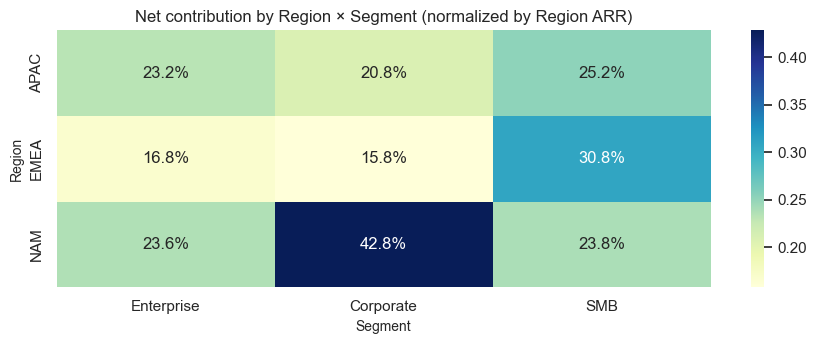

In [68]:
# Build Region x Segment matrix on normalized Net/ARR_region
region_segment_aggregated = data_processed.groupby(['region','segment']).agg(
    arr=('annual_contract_value','sum'),
    net=('net_arr_change','sum')
).reset_index()

arr_by_region = region_segment_aggregated.groupby('region')['arr'].sum().rename('arr_region')
region_segment_aggregated = region_segment_aggregated.merge(arr_by_region, on='region', how='left')
region_segment_aggregated['net_pct_region'] = np.where(region_segment_aggregated['arr_region']>0, region_segment_aggregated['net']/region_segment_aggregated['arr_region'], 0.0)

heatmap_input = region_segment_aggregated.rename(columns={'net_pct_region': 'delta_net_pct_region'})
plot_region_segment_heatmap(heatmap_input, 'Net contribution by Region × Segment (normalized by Region ARR)')

## 06 — Waterfall & trend analysis 
Visualize ARR movement by segment (Opening → Churn → Reactivation → New → Closing). Isolates dynamics and highlights growth drivers.


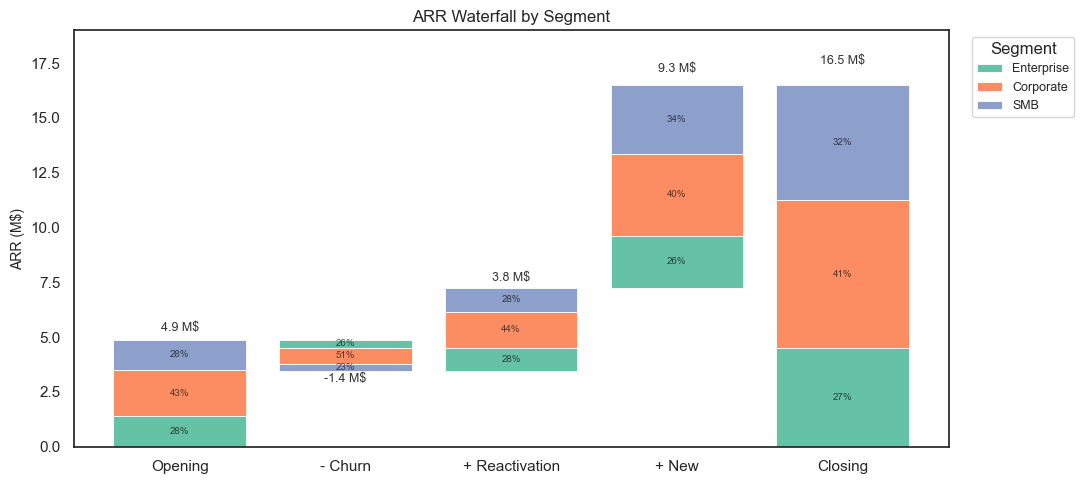

In [69]:
# Stacked waterfall by segment (cascade, M$) with connectors and % overlays
format_pct1 = lambda x: f"{x*100:.0f}%"

segment_waterfall = data_processed.groupby('segment').agg(
    opening_arr=('opening_arr','sum'),
    churned_arr=('churned_arr','sum'),
    reactivated_arr=('reactivated_arr','sum'),
    new_arr=('new_arr','sum')
).reset_index()
segment_waterfall['segment'] = pd.Categorical(segment_waterfall['segment'], categories=SEGMENT_ORDER, ordered=True)
segment_waterfall = segment_waterfall.sort_values('segment').reset_index(drop=True)

segment_waterfall['churned_arr'] = -segment_waterfall['churned_arr']
segment_waterfall['closing_arr'] = segment_waterfall['opening_arr'] + segment_waterfall['churned_arr'] + segment_waterfall['reactivated_arr'] + segment_waterfall['new_arr']

steps_order = ['Opening','- Churn','+ Reactivation','+ New','Closing']
value_cols = ['opening_arr','churned_arr','reactivated_arr','new_arr','closing_arr']
step_map = dict(zip(value_cols, steps_order))

waterfall_long_format = segment_waterfall.melt(id_vars='segment', value_vars=value_cols, var_name='step_key', value_name='value')
waterfall_long_format['Step'] = waterfall_long_format['step_key'].map(step_map)
waterfall_long_format['value_m'] = waterfall_long_format['value'] / 1e6

segment_order_present = [s for s in SEGMENT_ORDER if s in waterfall_long_format['segment'].unique()]
segments = segment_order_present
colors = sns.color_palette('Set2', n_colors=len(segments))
color_map = dict(zip(segments, colors))

step_totals = waterfall_long_format.groupby('Step')['value_m'].sum().reindex(steps_order)

# Compute cumulative position for each step (driving stacked bars)
y_start_tot = []
y_end_tot = []
cum = 0
for step in steps_order:
    if step == 'Opening':
        y_start_tot.append(0)
        cum = step_totals.loc[step]
        y_end_tot.append(cum)
    elif step == 'Closing':
        y_start_tot.append(0)
        y_end_tot.append(step_totals.loc[step])
    else:
        y_start_tot.append(cum)
        cum += step_totals.loc[step]
        y_end_tot.append(cum)

# Draw waterfall
fig, ax = plt.subplots(figsize=(11,5))
min_y = 0

for x, step in enumerate(steps_order):
    step_df = waterfall_long_format[waterfall_long_format['Step']==step]
    step_total = step_totals.loc[step]
    base = 0 if step in ['Opening','Closing'] else y_start_tot[x]
    pos_bottom = base
    neg_bottom = base
    
    # Stack segments for this step
    for seg_name in segments:
        v_series = step_df.loc[step_df['segment']==seg_name, 'value_m']
        if v_series.empty:
            continue
        v = v_series.iloc[0]
        
        # Draw bar
        bottom = pos_bottom if v >= 0 else neg_bottom
        ax.bar(x, v, bottom=bottom, color=color_map[seg_name], edgecolor='white', linewidth=0.6, label=seg_name if x==0 else "")
        
        # Label segment percentage
        if step not in ['Closing'] and step_total != 0:
            center = bottom + v/2
            ax.text(x, center, format_pct1(v/step_total), ha='center', va='center', fontsize=7, color='black', alpha=0.65)
        
        # Update position for next segment
        if v >= 0:
            pos_bottom += v
        else:
            neg_bottom += v
    
    min_y = min(min_y, neg_bottom)
    
    # Label step total
    label_offset = max(0.05 * abs(step_total), 0.05)
    label_y = (pos_bottom + label_offset) if step_total >= 0 else (neg_bottom - label_offset)
    ax.text(x, label_y, f"{step_total:,.1f} M$", ha='center', va='bottom' if step_total>=0 else 'top', fontsize=9, color='#333')
    
    # Label closing breakdown by segment
    if step == 'Closing' and step_total != 0:
        step_df_sorted = step_df.sort_values('value_m', ascending=False)
        running = 0
        for seg_name in segments:
            v_series = step_df_sorted.loc[step_df_sorted['segment']==seg_name, 'value_m']
            if v_series.empty:
                continue
            v = v_series.iloc[0]
            center = running + v/2
            ax.text(x, center, format_pct1(v/step_total), ha='center', va='center', fontsize=7, color='black', alpha=0.65)
            running += v

ax.set_xticks(range(len(steps_order)))
ax.set_xticklabels(steps_order)
ax.set_title('ARR Waterfall by Segment')
ax.set_ylabel('ARR (M$)')

# Adjust y-axis limits
y_all = y_end_tot + y_start_tot + [0, min(0, min_y)]
y_max_axis = max(y_all)
y_range = y_max_axis if y_max_axis > 0 else 1
ax.set_ylim(bottom=0, top=y_max_axis + 0.15*y_range)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, title='Segment', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.grid(False)
plt.tight_layout()
plt.show()



## Benchmarks comparison & key questions

### A) BENCHMARKS — For sanity checks

#### Retention Health (GRR—Gross Retention Rate)
| Segment | Healthy GRR Range | What it means |
|---------|-------------------|--------------|
| **Enterprise** | 94–98% | Losing 2–6% ARR to churn annually (best in class) |
| **Mid-Market** | 85–90% | Losing 10–15% ARR annually (expected volatility) |
| **SMB** | 65–80% | Losing 20–35% ARR annually (higher churn due to volatility) |

#### Net Growth (NRR—Net Retention Rate)
| Segment | Healthy NRR Range | What it means |
|---------|-------------------|--------------|
| **Enterprise/Mid-Market** | > 110% | Strong expansion—expansion ARR outpaces churn |
| **SMB** | 100–110% | Stable—less expansion room, but retention is solid |
| **All segments** | < 100% | ⚠️ Contraction—churn + reduction exceeds new expansion |

#### Reactivation (Win-back effectiveness)
| Reactivation Rate | Health Assessment |
|-------------------|-------------------|
| 10–20% of churned ARR | ✅ Healthy—good recovery mechanics |
| 5–10% of churned ARR | ⚠️ Moderate—room for win-back optimization |
| < 5% of churned ARR | ❌ Weak—ineffective win-back programs |

---

### B) CHECKLIST — What to verify in the data

**🔴 Retention Gaps** (highest priority)
- [ ] Enterprise GRR vs. benchmark (94–98%): above or below?
- [ ] Unexpected GRR inversions (SMB outperforming Enterprise = red flag)
- [ ] Churn concentration: Which regions/segments leak the most ARR?
- [ ] Trend: Is churn improving, stable, or worsening?

**🟡 Growth Composition** (second priority)
- [ ] NRR by segment: Which are > 100% (expanding) vs. < 100% (contracting)?
- [ ] Growth drivers: Is new ARR or expansion ARR carrying the weight?
- [ ] Expansion rates by segment: Where is land-and-expand working?

**🟢 Win-back Potential** (unlock quick wins)
- [ ] Reactivation % of churn: Is it 10–20% (healthy) or < 5% (opportunity)?
- [ ] Reactivation by segment: Which segments have best/worst recovery?
- [ ] Payoff ratio: Is reactivation cheaper/faster than acquiring new customers?

**🔵 Strategic Allocation** (where to invest)
- [ ] Region × Segment heatmap: Which cells contribute most net ARR?
- [ ] Priority ranking: Top 3–5 cells for retention investment
- [ ] Underperformers: Which segments need intervention first?


---

### C) DATASET CONTEXT — What's intentional in this simulation

This dataset **intentionally simulates a high-growth company in the retention-optimization phase**, not a mature, top-quartile business. Expect:

- **Higher churn than industry best-in-class** — Especially SMB and Mid-Market segments (deliberate; simulates acquisition-led growth)
- **Strong reactivation streams** — Showing effective win-back mechanics (deliberate; realistic for scaled operations)
- **Significant variance by region and segment** — Geographic and product-market fit differences (deliberate; real companies show this)

**Use the benchmarks above to identify where you are underperforming and ripe for intervention.**
